# Sistema de Evaluación de Riesgo Crediticio

## Notebook 01 — Análisis Exploratorio de Datos (EDA)

**Dataset:** Give Me Some Credit

**Objetivo:** Analizar la calidad de los datos, identificar valores faltantes, estudiar el desbalance de la variable objetivo y justificar las decisiones de preprocesamiento que se utilizarán en el modelo predictivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Información general del dataset

## 1.1 Carga del conjunto de datos

In [2]:
df = pd.read_csv(
    "../data/raw/cs-training.csv",
    index_col=0
)
df = df.rename(columns={"age": "Age"})
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1.2 Estadísticas descriptivas

In [3]:
df.shape
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   Age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


# 2. Análisis de valores faltantes

En esta sección se identifican las variables con valores faltantes y se calcula
su porcentaje dentro del conjunto de entrenamiento. Este análisis permitirá
definir posteriormente la estrategia de imputación utilizada durante el pipeline
de preprocesamiento.

In [4]:
missing = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean() * 100).round(2)
})

missing = (
    missing[missing["Valores nulos"] > 0]
    .sort_values("Porcentaje (%)", ascending=False)
)

missing

,Valores nulos,Porcentaje (%)
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


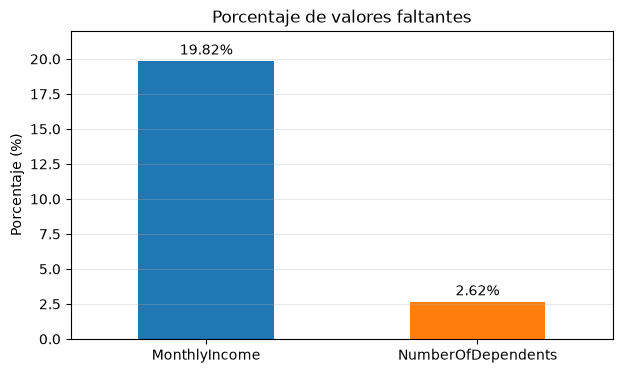

In [5]:
ax = missing["Porcentaje (%)"].plot(
    kind="bar",
    figsize=(7,4),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Porcentaje de valores faltantes")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.ylim(0, 22)

for i, value in enumerate(missing["Porcentaje (%)"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Conclusión

El análisis de valores faltantes evidencia que únicamente MonthlyIncome (19.82%) y NumberOfDependents (2.62%) presentan datos ausentes. Debido a que ambas corresponden a variables numéricas y el dataset contiene valores extremos propios del contexto financiero, la estrategia de imputación seleccionada será la mediana. Esta imputación se ajustará exclusivamente con el conjunto de entrenamiento durante el pipeline de preprocesamiento para evitar data leakage.

# 3. Análisis de la variable objetivo

La variable **SeriousDlqin2yrs** representa si un cliente experimentó una mora igual o superior a 90 días. En esta sección se analizará la distribución de clases para determinar si existe desbalance en el conjunto de entrenamiento.

In [6]:
target_counts = df["SeriousDlqin2yrs"].value_counts().sort_index()

target_counts

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [7]:
target_percentage = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

target_percentage

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

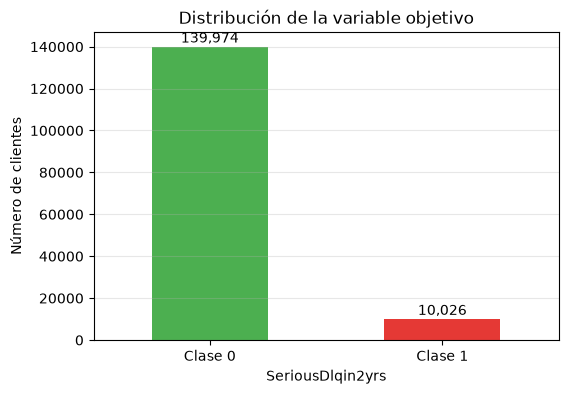

In [8]:
ax = target_counts.plot(
    kind="bar",
    figsize=(6,4),
    color=["#4CAF50", "#E53935"]
)

plt.title("Distribución de la variable objetivo")
plt.ylabel("Número de clientes")
plt.xticks([0,1], ["Clase 0", "Clase 1"], rotation=0)

for i, value in enumerate(target_counts):
    plt.text(i, value + 2000, f"{value:,}", ha="center")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Conclusión

La variable objetivo presenta un desbalance significativo, donde el 93.32% de los registros corresponde a clientes sin mora y únicamente el 6.68% a clientes con mora igual o superior a 90 días. Debido a esta distribución, el entrenamiento de la regresión logística utilizará el parámetro class_weight="balanced", permitiendo asignar un mayor peso a la clase minoritaria sin alterar la composición original del dataset.

# 4. Análisis de outliers
En esta sección se analizan las principales variables financieras para identificar la presencia de valores atípicos mediante diagramas de caja y la regla del rango intercuartílico (IQR). Este análisis permitirá justificar la necesidad de estandarizar los datos antes de aplicar PCA.

In [9]:
numeric_summary = df.describe().T

numeric_summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,0.07,0.25,0.0,0.00,0.00,0.00,1.0
RevolvingUtilizationOfUnsecuredLines,6.05,249.76,0.0,0.03,0.15,0.56,50708.0
Age,52.30,14.77,0.0,41.00,52.00,63.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,0.42,4.19,0.0,0.00,0.00,0.00,98.0
DebtRatio,353.01,2037.82,0.0,0.18,0.37,0.87,329664.0
MonthlyIncome,6670.22,14384.67,0.0,3400.00,5400.00,8249.00,3008750.0
NumberOfOpenCreditLinesAndLoans,8.45,5.15,0.0,5.00,8.00,11.00,58.0
NumberOfTimes90DaysLate,0.27,4.17,0.0,0.00,0.00,0.00,98.0
NumberRealEstateLoansOrLines,1.02,1.13,0.0,0.00,1.00,2.00,54.0
NumberOfTime60-89DaysPastDueNotWorse,0.24,4.16,0.0,0.00,0.00,0.00,98.0


C:\Users\User\AppData\Local\Temp\ipykernel_16244\999367693.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_16244\999367693.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_16244\999367693.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_16244\999367693.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_16244\9993676

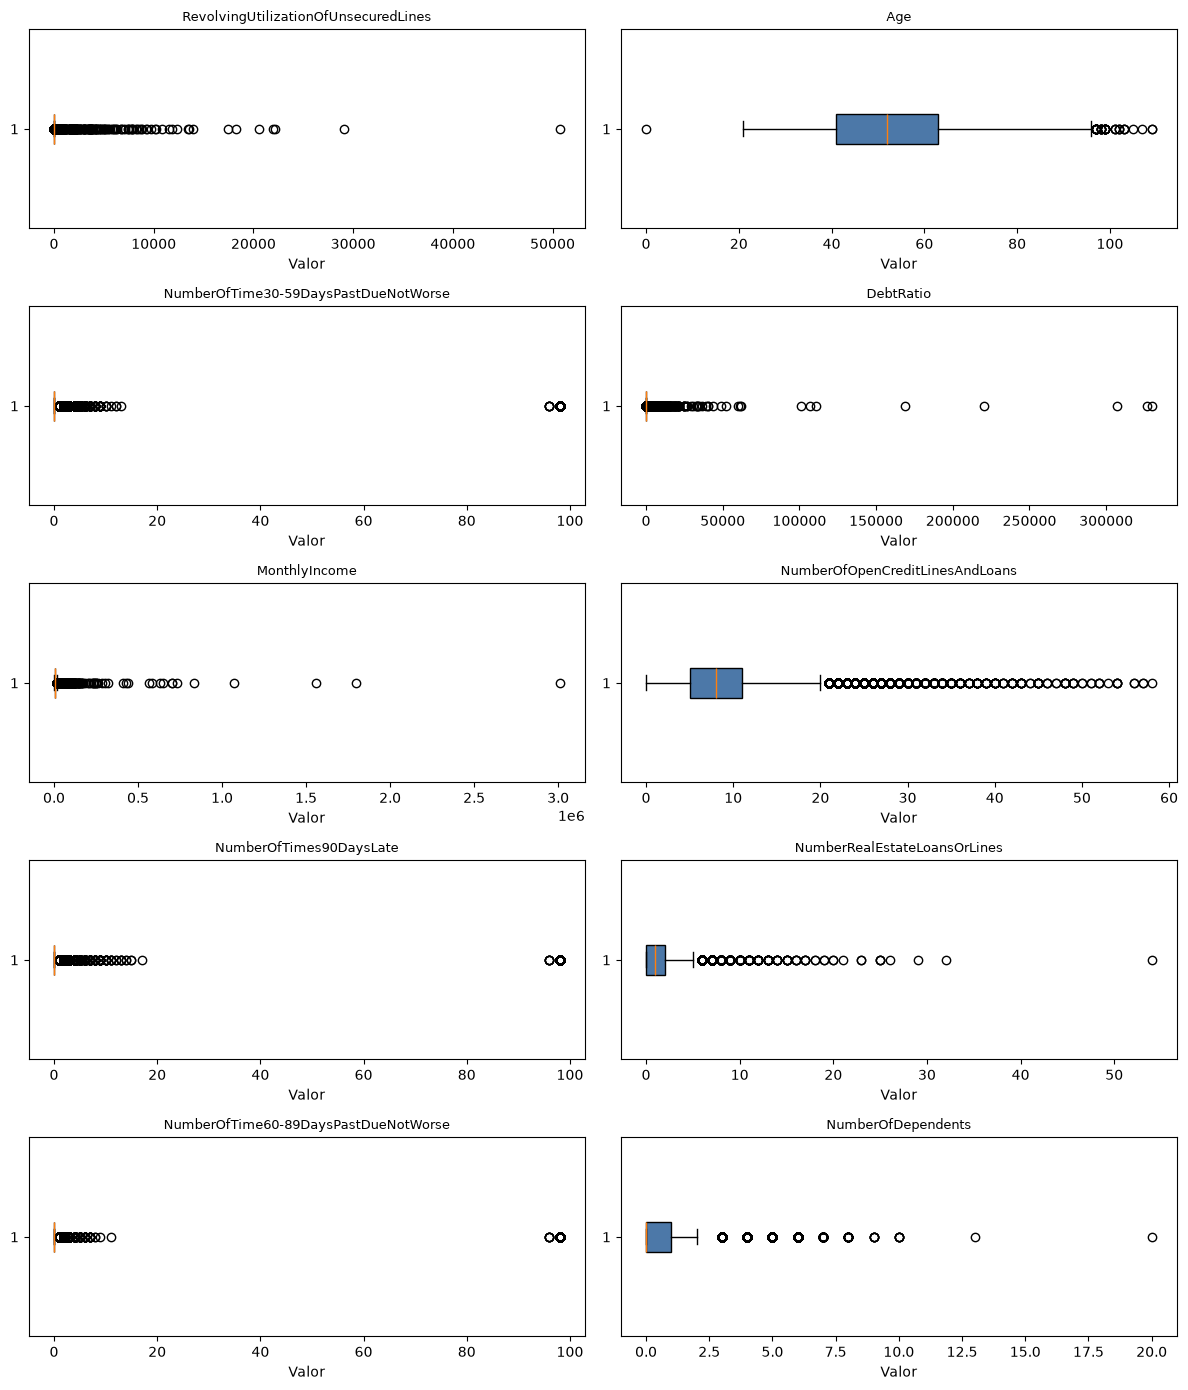

In [10]:
predictors = df.drop(columns=["SeriousDlqin2yrs"])

fig, axes = plt.subplots(5, 2, figsize=(12, 14))
axes = axes.flatten()

for ax, col in zip(axes, predictors.columns):
    ax.boxplot(
        predictors[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="#4C78A8")
    )
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Valor")

plt.tight_layout()
plt.show()

In [11]:
outliers = []

for col in predictors.columns:
    q1 = predictors[col].quantile(0.25)
    q3 = predictors[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((predictors[col] < lower) | (predictors[col] > upper)).sum()

    outliers.append({
        "Variable": col,
        "Outliers": count,
        "Porcentaje": round(count / len(df) * 100, 2)
    })

outlier_df = (
    pd.DataFrame(outliers)
      .sort_values("Porcentaje", ascending=False)
)

outlier_df

,Variable,Outliers,Porcentaje
3,DebtRatio,31311,20.87
2,NumberOfTime30-59DaysPastDueNotWorse,23982,15.99
9,NumberOfDependents,13336,8.89
6,NumberOfTimes90DaysLate,8338,5.56
8,NumberOfTime60-89DaysPastDueNotWorse,7604,5.07
4,MonthlyIncome,4879,3.25
5,NumberOfOpenCreditLinesAndLoans,3980,2.65
7,NumberRealEstateLoansOrLines,793,0.53
0,RevolvingUtilizationOfUnsecuredLines,763,0.51
1,Age,46,0.03


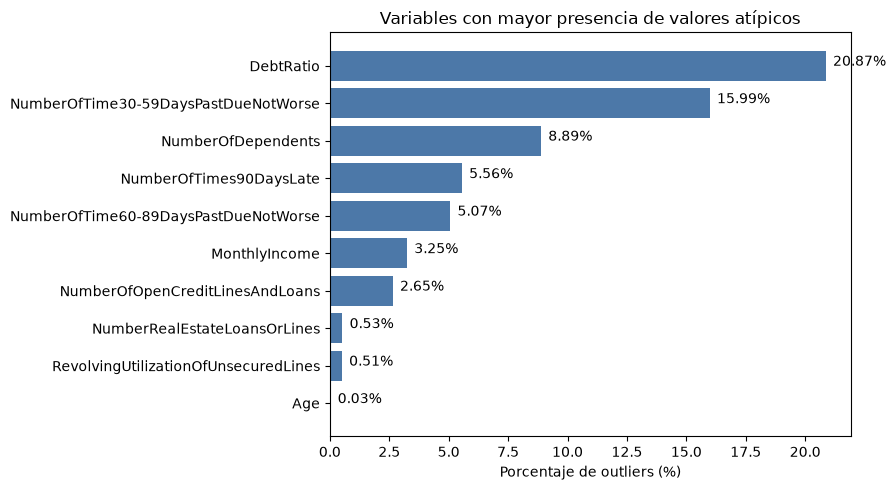

In [12]:
plt.figure(figsize=(9,5))

plt.barh(
    outlier_df["Variable"],
    outlier_df["Porcentaje"],
    color="#4C78A8"
)

plt.xlabel("Porcentaje de outliers (%)")
plt.title("Variables con mayor presencia de valores atípicos")
plt.gca().invert_yaxis()

for i, value in enumerate(outlier_df["Porcentaje"]):
    plt.text(value + 0.3, i, f"{value:.2f}%")

plt.tight_layout()
plt.show()

El análisis mediante boxplots evidencia una presencia considerable de valores atípicos en varias variables financieras y de historial crediticio. La variable DebtRatio presenta la mayor proporción de outliers (20.87%), seguida por los indicadores de morosidad entre 30 y 59 días (15.99%). Estos resultados muestran que las variables poseen magnitudes y dispersiones muy diferentes, por lo que será necesario aplicar una estandarización con StandardScaler antes de realizar el Análisis de Componentes Principales (PCA). Los valores extremos se conservarán en el dataset, ya que pueden representar comportamientos financieros reales y no necesariamente errores de registro.

# 5. Análisis de correlación entre variables

En esta sección se analiza la relación lineal entre las variables financieras
mediante la matriz de correlación de Pearson. Este análisis permite identificar
posibles redundancias entre características y justifica la aplicación posterior
del Análisis de Componentes Principales (PCA).

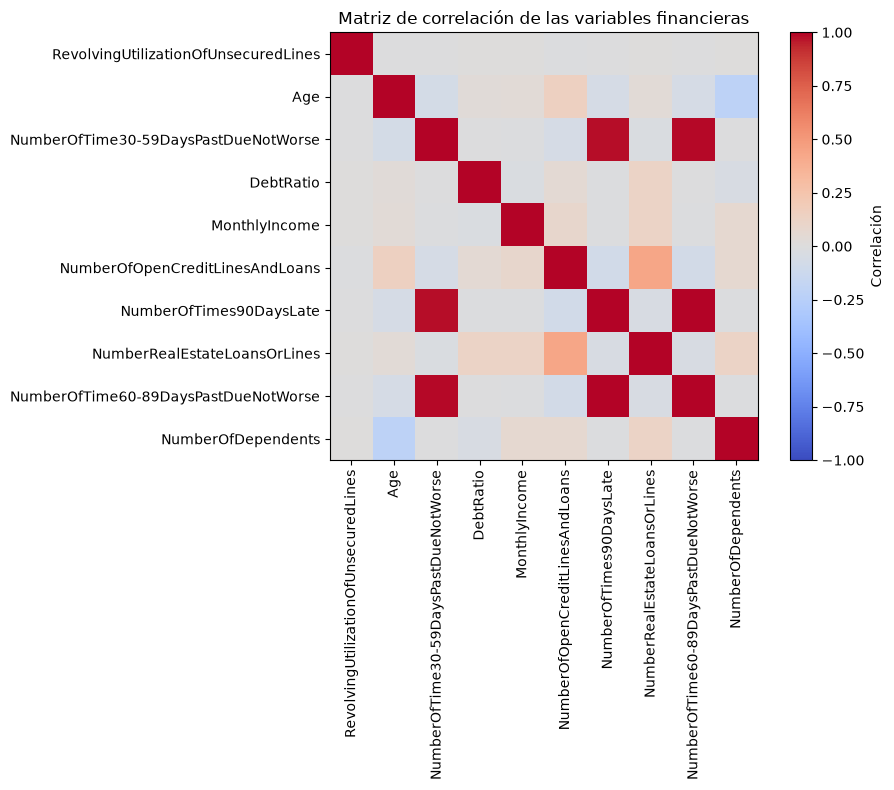

In [ ]:
corr = df.drop(columns=["SeriousDlqin2yrs"]).corr(numeric_only=True)

plt.figure(figsize=(10,8))

im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(im, label="Correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación de las variables financieras")
plt.tight_layout()
plt.show()

In [14]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

corr_pairs["Abs"] = corr_pairs["Correlación"].abs()

top_corr = (
    corr_pairs
    .sort_values("Abs", ascending=False)
    .drop_duplicates("Abs")
    .head(10)
)

top_corr[["Variable 1", "Variable 2", "Correlación"]]

,Variable 1,Variable 2,Correlación
68,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,0.992796
28,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,0.987005
62,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,0.983603
57,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,0.433959
19,Age,NumberOfDependents,-0.213303
51,NumberOfOpenCreditLinesAndLoans,Age,0.147705
47,MonthlyIncome,NumberRealEstateLoansOrLines,0.124959
97,NumberOfDependents,NumberRealEstateLoansOrLines,0.124684
73,NumberRealEstateLoansOrLines,DebtRatio,0.120046
45,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,0.091455


### Conclusión
La matriz de correlación evidencia una alta redundancia entre los indicadores de morosidad, alcanzando correlaciones de hasta 0.993 entre las variables NumberOfTimes90DaysLate y NumberOfTime60-89DaysPastDueNotWorse. Este resultado sugiere que dichas características comparten gran parte de su información, por lo que resulta apropiado aplicar el Análisis de Componentes Principales (PCA) para condensar esa variabilidad en un número reducido de componentes. En contraste, el resto de variables presenta correlaciones bajas o moderadas, indicando que aportan información complementaria al modelo.

In [15]:
output_path = "../data/processed/training_clean.parquet"

df.to_parquet(output_path, index=False)

print(f"Dataset exportado en: {output_path}")

Dataset exportado en: ../data/processed/training_clean.parquet


# 6. Decisiones metodológicas del proyecto

A partir del análisis exploratorio se establecen las siguientes decisiones para el pipeline de entrenamiento:

| Decisión | Justificación |
|----------|---------------|
| Imputación por mediana | MonthlyIncome y NumberOfDependents contienen valores faltantes. |
| class_weight="balanced" | La clase positiva representa únicamente el 6.68% del dataset. |
| StandardScaler | Las variables presentan escalas y dispersiones muy diferentes. |
| PCA | Reducir la redundancia entre variables altamente correlacionadas y obtener una representación de menor dimensión para comparar su impacto en el desempeño del modelo. |
| Parquet | Almacenamiento eficiente y reutilizable para el pipeline. |